# Linear Regression model:

Starting from your saved feature file. I’ll show you step by step how to:

Load the TSV features back into Python.

Separate X and y (features and target).

Split into train/test for evaluation.

Train a Linear Regression model.

Evaluate the performance.

# 1) Config + load features (X) and labels (y)

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


FEATURE_PATH = "../data/feature_vectors/X_full.tsv"   # swap to X_kmer.tsv, X_binary.tsv, or X_full.tsv later


/Users/darsa/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
df_feat = pd.read_csv(FEATURE_PATH, sep="\t")
df_feat

,0,1,2,3,4,5,6,7,8,9,...,601,602,603,604,605,606,607,608,609,label
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.571429,0.523810,0.476190,0.619048,0.380952,0.428571,0.571429,0.380952,0.619048,0.00
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.666667,0.571429,0.428571,0.380952,0.619048,0.380952,0.619048,0.476190,0.523810,0.00
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.666667,0.571429,0.428571,0.380952,0.619048,0.380952,0.619048,0.476190,0.523810,0.00
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.571429,0.666667,0.333333,0.523810,0.476190,0.428571,0.571429,0.285714,0.714286,0.00
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.571429,0.666667,0.333333,0.523810,0.476190,0.428571,0.571429,0.285714,0.714286,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4430,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.619048,0.476190,0.523810,0.523810,0.476190,0.380952,0.619048,0.428571,0.571429,98.70
4431,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.714286,0.571429,0.428571,0.428571,0.571429,0.285714,0.714286,0.333333,0.666667,98.76
4432,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.619048,0.476190,0.523810,0.523810,0.476190,0.380952,0.619048,0.428571,0.571429,98.81
4433,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.571429,0.428571,0.571429,0.523810,0.476190,0.428571,0.571429,0.476190,0.523810,99.00


In [6]:
# Last column is the target label (as saved earlier)
label_col = "label" if "label" in df_feat.columns else df_feat.columns[-1]
X = df_feat.drop(columns=[label_col]).to_numpy(dtype=float)
y = df_feat[label_col].to_numpy(dtype=float)

print("Loaded:", FEATURE_PATH)
print("Shapes -> X:", X.shape, " y:", y.shape)

Loaded: ../data/feature_vectors/X_full.tsv
Shapes -> X: (4435, 610)  y: (4435,)


In [7]:
X_train, X_ind, y_train, y_ind = train_test_split(
    X, y, test_size=0.20, shuffle=True, random_state=42
)

print("Train:", X_train.shape, "Independent 20%:", X_ind.shape)


Train: (3548, 610) Independent 20%: (887, 610)


# We repeatedly split the 80% into 10 folds, train on 9/10, validate on 1/10, and report Pearson correlation each time. The mean±std gives stability/variance.

In [9]:
def _pcc(y_true, y_pred):
    return float(np.corrcoef(y_true, y_pred)[0, 1])

pcc_scorer = make_scorer(_pcc, greater_is_better=True)

cv = KFold(n_splits=10, shuffle=True, random_state=42)
lin = LinearRegression()

# 10-fold CV PCC on the 80% training data
pcc_cv = cross_val_score(lin, X_train, y_train, cv=cv, scoring=pcc_scorer)
print("PCC (10-fold CV on 80% train)")
print("  per-fold:", np.round(pcc_cv, 4))
print("  mean ± std: {:.4f} ± {:.4f}".format(pcc_cv.mean(), pcc_cv.std()))


PCC (10-fold CV on 80% train)
  per-fold: [-0.0448 -0.0334  0.0792  0.3422  0.0087 -0.0544 -0.032  -0.0305 -0.006
 -0.073 ]
  mean ± std: 0.0156 ± 0.1159


# 4) Fit on the full 80% and evaluate on the 20% independent holdout

In [10]:
lin.fit(X_train, y_train)
y_pred_ind = lin.predict(X_ind)

# Report PCC + a few standard regression metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def _pcc_print(y_true, y_pred): return float(np.corrcoef(y_true, y_pred)[0, 1])

print("\nIndependent 20% evaluation (never seen during CV):")
print("  PCC:", _pcc_print(y_ind, y_pred_ind))
print("  R^2:", r2_score(y_ind, y_pred_ind))
print("  MSE:", mean_squared_error(y_ind, y_pred_ind))
print("  MAE:", mean_absolute_error(y_ind, y_pred_ind))



Independent 20% evaluation (never seen during CV):
  PCC: -0.015026839148484546
  R^2: -1.8171678255992218e+23
  MSE: 1.6257305152110898e+26
  MAE: 678502312924.4639


# Quick visuals on the 20% (parity + residuals)

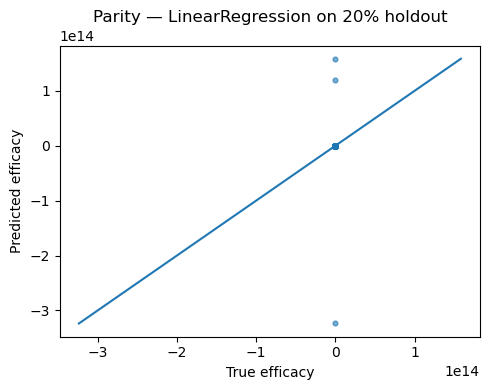

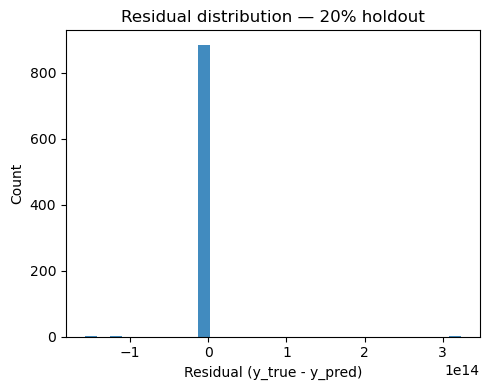

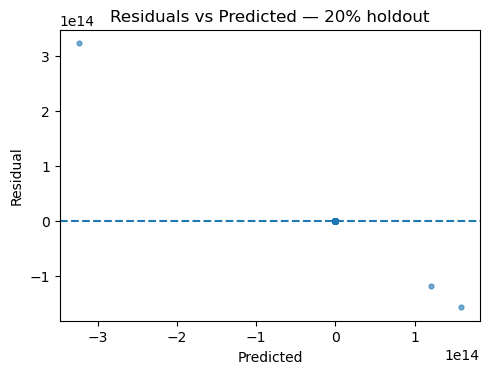

In [11]:
# Parity: predicted vs true
plt.figure(figsize=(5,4))
plt.scatter(y_ind, y_pred_ind, alpha=0.6, s=12)
lims = [min(y_ind.min(), y_pred_ind.min()), max(y_ind.max(), y_pred_ind.max())]
plt.plot(lims, lims)
plt.xlabel("True efficacy")
plt.ylabel("Predicted efficacy")
plt.title("Parity — LinearRegression on 20% holdout")
plt.tight_layout()
plt.show()

# Residuals
res = y_ind - y_pred_ind

plt.figure(figsize=(5,4))
plt.hist(res, bins=30, alpha=0.85)
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Residual distribution — 20% holdout")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(y_pred_ind, res, alpha=0.6, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted — 20% holdout")
plt.tight_layout()
plt.show()


##  Above...
Parity plot close to the diagonal ⇒ better predictions.

Residual histogram centered at 0 and tight ⇒ lower error.

Residuals vs Predicted should look like noise (no pattern).

# Why the plot looks strange ?

The parity plot (True vs Predicted efficacy) should normally show points scattered around the diagonal line (y = x).

In your figure, the axis labels are in the range of 1e14 (hundreds of trillions). That suggests that your model or your data blew up to extremely large values.

This can happen if:

Features weren’t scaled properly (Linear Regression is sensitive to very large/sparse values).

There’s multicollinearity or redundant features (lots of zeros/ones in one-hot, and many correlated k-mers).

The labels (efficacy) are not normalized or have outliers.

So the diagonal line is there (that’s the “perfect prediction” line), but your points are way off in strange positions — meaning the model is not learning meaningful relationships.




# Why PCC is poor ?

Pearson correlation (PCC) measures whether predicted and true values rise/fall together.

If predictions are essentially noise or a constant offset, PCC will be low.

A bad PCC here means your model isn’t capturing the patterns in efficacy from your features.

# How to improve ?

To get better, you should try a few things:

a) Feature scaling / normalization

Apply StandardScaler to your features before feeding into Linear Regression.

This prevents large numbers from dominating the regression weights.

b) Regularization

Try Ridge or Lasso regression (with hyperparameter tuning). These handle correlated features and prevent coefficient explosion.

c) Sanity check labels

Plot histogram of your y values (efficacy). Are they in a sensible range (like 0–100 or 0–1)?

If they’re extreme or mixed (e.g. integer counts vs probabilities), you may need to transform them.

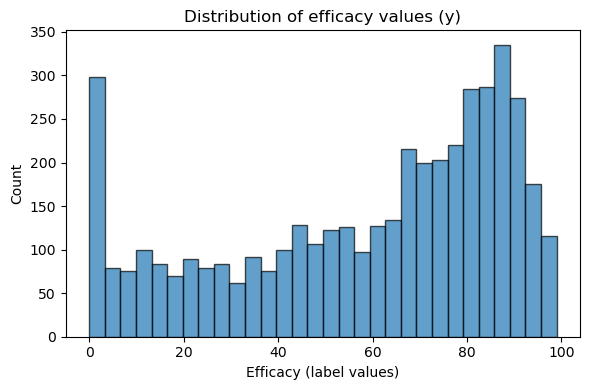

y min: 0.0  y max: 99.0
y mean: 58.37055242390079  y std: 29.612597520959646


In [13]:
# Histogram
plt.figure(figsize=(6,4))
plt.hist(y, bins=30, edgecolor="k", alpha=0.7)
plt.xlabel("Efficacy (label values)")
plt.ylabel("Count")
plt.title("Distribution of efficacy values (y)")
plt.tight_layout()
plt.show()

print("y min:", y.min(), " y max:", y.max())
print("y mean:", y.mean(), " y std:", y.std())

# END of File